# Baseline GitHub Issue Classifier

This notebook trains baseline classifiers for the NLBSE'24 issue-report classification data in this repository. The task is to classify issues as `bug`, `feature`, or `question`.

We keep the provided train/test split intact, compare a text-only model with a text-plus-repository model, save figures to `outputs/figures/`, and save predictions to `outputs/predictions/`.

## Plan

- Use `data/issues_train.csv` for training and `data/issues_test.csv` only for final evaluation.
- Build text from `title + body`.
- Fill missing bodies with empty strings.
- Preprocess issue text by removing HTML comments/tags, replacing URLs and fenced code blocks with placeholder tokens, and normalizing whitespace.
- Compare two sklearn pipelines:
  - text-only: TF-IDF over cleaned issue text + logistic regression
  - text + repo: TF-IDF over cleaned issue text plus one-hot encoded `repo` + logistic regression
- Report accuracy, macro F1, weighted F1, per-class metrics, and confusion matrices.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from bs4 import BeautifulSoup
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=UserWarning, module="bs4")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "issues_train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
LABEL_ORDER = ["bug", "feature", "question"]

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/cgamboa/git/FCUL-Agentic-AI-Class


## Load Data

In [2]:
train_df = pd.read_csv(DATA_DIR / "issues_train.csv")
test_df = pd.read_csv(DATA_DIR / "issues_test.csv")

display(train_df.head())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Columns:", list(train_df.columns))

,repo,created_at,label,title,body
0,facebook/react,2023-08-26 06:33:37,bug,"[DevTools Bug] Cannot add node ""1"" because a n...",### Website or app\n\nPrivate repo cannot give...
1,facebook/react,2023-07-28 05:16:12,bug,[DevTools Bug]: Devtools extension build faili...,### Website or app\n\nN/A\n\n### Repro steps\n...
2,facebook/react,2023-07-13 21:58:31,bug,[DevTools Bug]: Deprecated __REACT_DEVTOOLS_GL...,### Website or app\n\nhttps://github.com/open-...
3,facebook/react,2023-06-14 02:31:20,bug,"[DevTools Bug] Cannot remove node ""0"" because ...",### Website or app\n\nlocal\n\n### Repro steps...
4,facebook/react,2023-06-03 11:29:44,bug,"[DevTools Bug] Cannot remove node ""103"" becaus...",### Website or app\n\nlocalhost\n\n### Repro s...


Train shape: (1500, 5)
Test shape: (1500, 5)
Columns: ['repo', 'created_at', 'label', 'title', 'body']


In [3]:
overview = pd.DataFrame(
    {
        "train_missing": train_df.isna().sum(),
        "test_missing": test_df.isna().sum(),
        "train_unique": train_df.nunique(),
        "test_unique": test_df.nunique(),
    }
)
display(overview)

display(pd.crosstab(train_df["repo"], train_df["label"]))
display(pd.crosstab(test_df["repo"], test_df["label"]))

,train_missing,test_missing,train_unique,test_unique
repo,0,0,5,5
created_at,0,0,1500,1500
label,0,0,3,3
title,0,0,1481,1490
body,0,2,1492,1488


label,bug,feature,question
repo,,,
bitcoin/bitcoin,100,100,100
facebook/react,100,100,100
microsoft/vscode,100,100,100
opencv/opencv,100,100,100
tensorflow/tensorflow,100,100,100


label,bug,feature,question
repo,,,
bitcoin/bitcoin,100,100,100
facebook/react,100,100,100
microsoft/vscode,100,100,100
opencv/opencv,100,100,100
tensorflow/tensorflow,100,100,100


## Dataset Plots

Saved outputs/figures/label_distribution.png


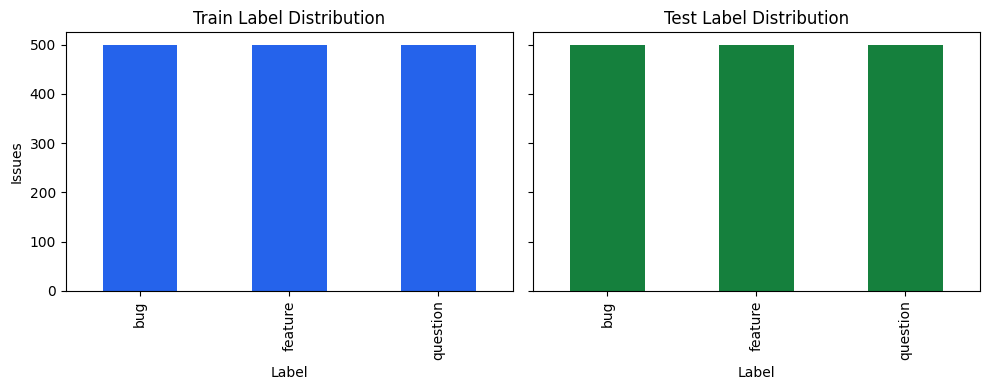

In [4]:
def save_current_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
train_df["label"].value_counts().reindex(LABEL_ORDER).plot(kind="bar", ax=axes[0], color="#2563eb")
test_df["label"].value_counts().reindex(LABEL_ORDER).plot(kind="bar", ax=axes[1], color="#15803d")
axes[0].set_title("Train Label Distribution")
axes[1].set_title("Test Label Distribution")
for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Issues")
save_current_figure("label_distribution.png")
plt.show()

Saved outputs/figures/repository_distribution.png


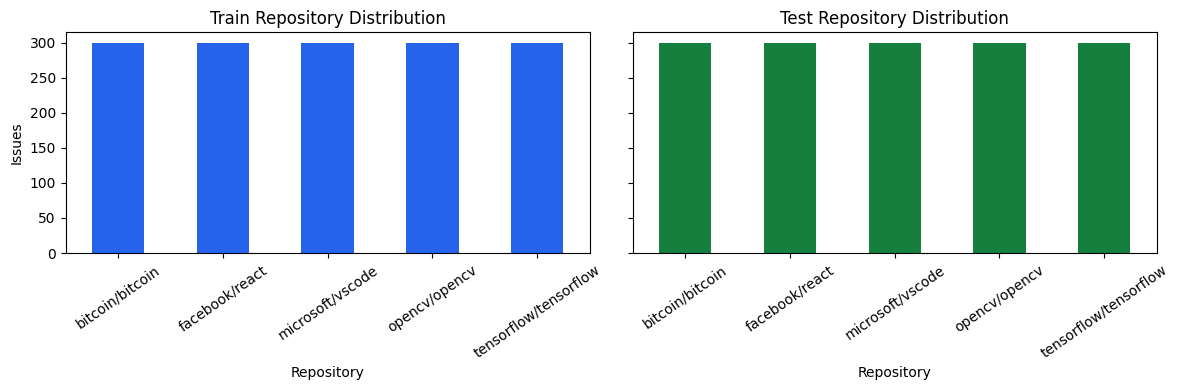

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
train_df["repo"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#2563eb")
test_df["repo"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#15803d")
axes[0].set_title("Train Repository Distribution")
axes[1].set_title("Test Repository Distribution")
for ax in axes:
    ax.set_xlabel("Repository")
    ax.set_ylabel("Issues")
    ax.tick_params(axis="x", rotation=35)
save_current_figure("repository_distribution.png")
plt.show()

,title_chars,body_chars,combined_words
count,1500.0,1500.0,1500.0
mean,55.9,2335.7,236.6
std,28.9,7713.4,661.6
min,1.0,1.0,2.0
25%,37.0,564.5,79.0
50%,52.0,1091.0,150.0
75%,68.0,2176.2,244.0
max,293.0,207777.0,21595.0


,title_chars,body_chars,combined_words
count,1500.0,1500.0,1500.0
mean,56.5,2178.6,224.2
std,28.9,4494.1,350.2
min,1.0,0.0,1.0
25%,38.0,614.0,89.0
50%,52.0,1120.5,151.0
75%,69.0,2146.0,241.2
max,284.0,61610.0,5050.0


Saved outputs/figures/text_length_distribution.png


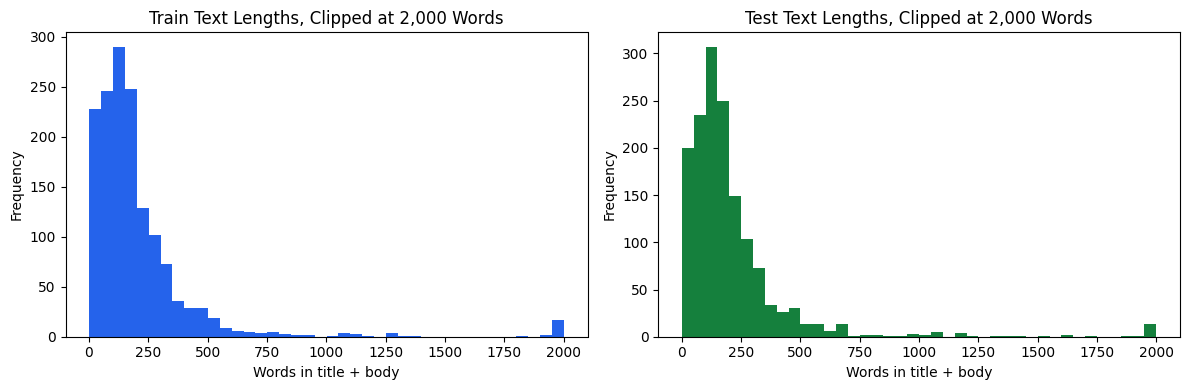

In [6]:
for df in [train_df, test_df]:
    df["body_filled"] = df["body"].fillna("")
    df["title_chars"] = df["title"].fillna("").str.len()
    df["body_chars"] = df["body_filled"].str.len()
    df["combined_words"] = (df["title"].fillna("") + " " + df["body_filled"]).str.split().str.len()

display(train_df[["title_chars", "body_chars", "combined_words"]].describe().round(1))
display(test_df[["title_chars", "body_chars", "combined_words"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["combined_words"].clip(upper=2000).plot(kind="hist", bins=40, ax=axes[0], color="#2563eb")
test_df["combined_words"].clip(upper=2000).plot(kind="hist", bins=40, ax=axes[1], color="#15803d")
axes[0].set_title("Train Text Lengths, Clipped at 2,000 Words")
axes[1].set_title("Test Text Lengths, Clipped at 2,000 Words")
for ax in axes:
    ax.set_xlabel("Words in title + body")
save_current_figure("text_length_distribution.png")
plt.show()

## Preprocessing

The baseline keeps preprocessing practical rather than elaborate. It handles the data issues found during exploration: missing bodies, HTML templates/comments, fenced code blocks, URLs, and noisy whitespace.

In [7]:
HTML_COMMENT_RE = re.compile(r"<!--.*?-->", flags=re.DOTALL)
FENCED_CODE_RE = re.compile(r"```.*?```", flags=re.DOTALL)
URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
WHITESPACE_RE = re.compile(r"\s+")


def clean_issue_text(value):
    if pd.isna(value):
        return ""
    text = str(value)
    text = HTML_COMMENT_RE.sub(" ", text)
    text = FENCED_CODE_RE.sub(" CODE_BLOCK ", text)
    text = URL_RE.sub(" URL ", text)
    text = BeautifulSoup(text, "lxml").get_text(" ")
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text


class IssueTextBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        frame = pd.DataFrame(X, columns=["title", "body"])
        title = frame["title"].fillna("").map(clean_issue_text)
        body = frame["body"].fillna("").map(clean_issue_text)
        return (title + "\n\n" + body).to_numpy()


sample = test_df.loc[test_df["body"].isna(), ["title", "body"]].head()
display(sample)

,title,body
292,Why can't we use both prevstate (function) + c...,NaN
1095,void,NaN


## Model Pipelines

In [8]:
text_features = Pipeline(
    steps=[
        ("build_text", IssueTextBuilder()),
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_features=50_000,
                sublinear_tf=True,
            ),
        ),
    ]
)

text_only_preprocessor = ColumnTransformer(
    transformers=[("text", text_features, ["title", "body"])],
    remainder="drop",
)

text_repo_preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_features, ["title", "body"]),
        ("repo", OneHotEncoder(handle_unknown="ignore"), ["repo"]),
    ],
    remainder="drop",
)


def make_model(preprocessor):
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


models = {
    "text_only": make_model(text_only_preprocessor),
    "text_plus_repo": make_model(text_repo_preprocessor),
}

X_train = train_df[["repo", "title", "body"]]
y_train = train_df["label"]
X_test = test_df[["repo", "title", "body"]]
y_test = test_df["label"]

## Train and Evaluate

In [9]:
results = []
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_f1": f1_score(y_test, y_pred, average="macro"),
            "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
        }
    )
    print(classification_report(y_test, y_pred, labels=LABEL_ORDER))

results_df = pd.DataFrame(results).set_index("model")
display(results_df.round(4))

Training text_only...
              precision    recall  f1-score   support

         bug       0.83      0.72      0.77       500
     feature       0.73      0.84      0.78       500
    question       0.74      0.74      0.74       500

    accuracy                           0.76      1500
   macro avg       0.77      0.76      0.76      1500
weighted avg       0.77      0.76      0.76      1500

Training text_plus_repo...
              precision    recall  f1-score   support

         bug       0.81      0.72      0.76       500
     feature       0.75      0.83      0.79       500
    question       0.73      0.75      0.74       500

    accuracy                           0.76      1500
   macro avg       0.77      0.76      0.76      1500
weighted avg       0.77      0.76      0.76      1500



,accuracy,macro_f1,weighted_f1
model,,,
text_only,0.7647,0.7644,0.7644
text_plus_repo,0.7633,0.7630,0.7630


Saved outputs/figures/model_comparison.png


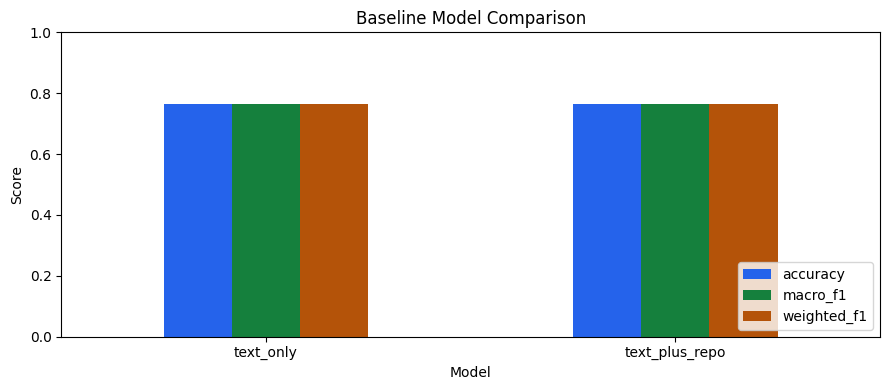

In [10]:
ax = results_df[["accuracy", "macro_f1", "weighted_f1"]].plot(kind="bar", figsize=(9, 4), ylim=(0, 1), color=["#2563eb", "#15803d", "#b45309"])
ax.set_title("Baseline Model Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
save_current_figure("model_comparison.png")
plt.show()

Saved outputs/figures/confusion_matrix_text_only.png


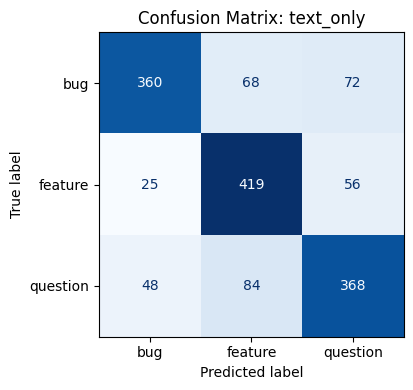

Saved outputs/figures/confusion_matrix_text_plus_repo.png


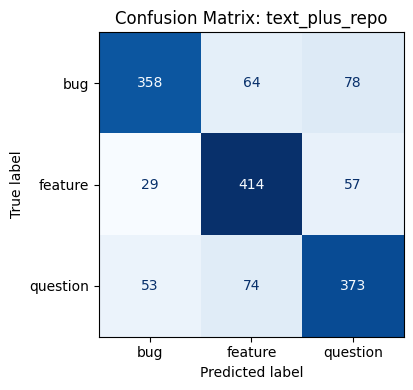

In [11]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
    save_current_figure(f"confusion_matrix_{name}.png")
    plt.show()

## Save Predictions

In [12]:
prediction_df = test_df[["repo", "created_at", "label", "title"]].copy()
for name, y_pred in predictions.items():
    prediction_df[f"pred_{name}"] = y_pred
    prediction_df[f"correct_{name}"] = prediction_df[f"pred_{name}"] == prediction_df["label"]

prediction_path = PREDICTION_DIR / "baseline_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)
print(f"Saved {prediction_path.relative_to(PROJECT_ROOT)}")
display(prediction_df.head())

Saved outputs/predictions/baseline_predictions.csv


,repo,created_at,label,title,pred_text_only,correct_text_only,pred_text_plus_repo,correct_text_plus_repo
0,facebook/react,2023-08-02 02:26:00,bug,Bug: [18.3.0-canary] renderToString hoists som...,bug,True,bug,True
1,facebook/react,2023-07-17 22:43:05,bug,[DevTools Bug]: Chrome extension gets disconne...,bug,True,bug,True
2,facebook/react,2023-07-13 19:01:47,bug,[DevTools Bug]: Deprecated __REACT_DEVTOOLS_GL...,bug,True,bug,True
3,facebook/react,2023-06-07 17:26:43,bug,[DevTools Bug]: React devtools stuck at Loadin...,bug,True,bug,True
4,facebook/react,2023-05-31 15:17:41,bug,Bug: Radio button onChange not called in curre...,bug,True,bug,True


## Quick Error Analysis

Look at a few examples where the stronger baseline failed. This is intentionally small and human-readable; deeper error analysis can group failures by repo, label pair, or text pattern.

In [13]:
focus_model = "text_plus_repo"
errors = prediction_df.loc[~prediction_df[f"correct_{focus_model}"]].copy()
print(f"{focus_model} errors: {len(errors)} / {len(prediction_df)}")
display(errors[["repo", "label", f"pred_{focus_model}", "title"]].head(12))

text_plus_repo errors: 355 / 1500


,repo,label,pred_text_plus_repo,title
14,facebook/react,bug,question,Bug: Error occurs when returning empty fragmen...
38,facebook/react,bug,question,Bug: out of order application of useState changes
53,facebook/react,bug,question,Bug: setState is not flushed if an iframe is a...
56,facebook/react,bug,question,Bug: Incorrect Hydration Mismatch Detection du...
57,facebook/react,bug,question,Bug: Some transition updates haven't been rend...
58,facebook/react,bug,question,Bug: componentWillUnmount is called twice
65,facebook/react,bug,feature,renderToReadableStream Passes Reusable Chunks
72,facebook/react,bug,question,"[DevTools]: Confusing ""Why did this render?"" w..."
87,facebook/react,bug,question,Named hooks parsing fails for certain Code San...
94,facebook/react,bug,question,"Bug: setState updater called but not rendered,..."


## Notes

- Including `repo` is useful as a comparison, but it can encode project-specific shortcuts. For a model expected to generalize to unseen repositories, prefer the text-only baseline or evaluate with repository-held-out validation.
- The provided test split should stay untouched until final evaluation. Use only the training CSV for hyperparameter tuning.
- If a future run scores suspiciously high, check for leakage: fitting TF-IDF on train+test, using labels in preprocessing, or evaluating on the training data.